In [1]:
import os
import glob
import matplotlib.pyplot as plt
from PIL import Image
from keras import __version__
from keras.applications import MobileNetV2
from keras.applications.mobilenet_v2 import preprocess_input
from keras.models import Model
from keras.layers import Dense, GlobalAveragePooling2D
from keras.preprocessing.image import ImageDataGenerator
from keras.optimizers import Adam, SGD
from keras.models import Sequential
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions
import numpy as np


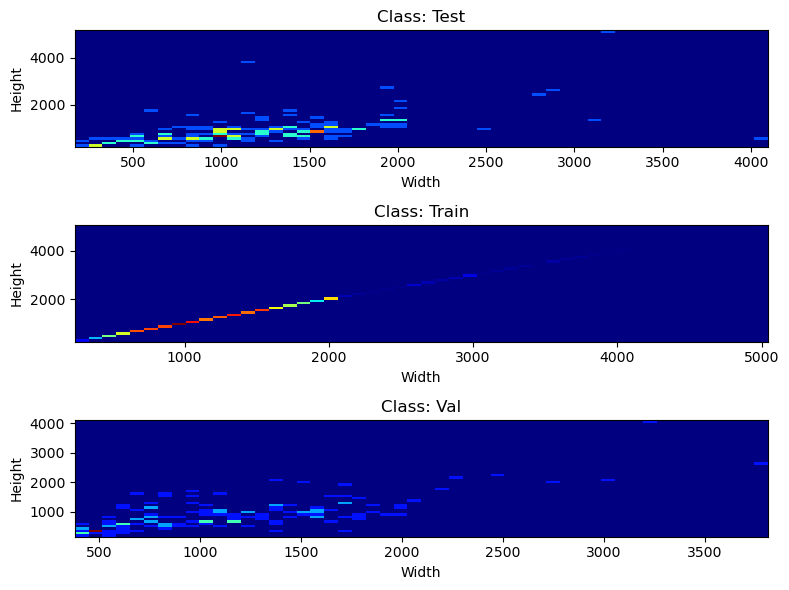

In [2]:
from PIL import Image
import os
import matplotlib.pyplot as plt

def plot_image_shapes(dataset_folder):
    class_shapes = {}

    for class_folder in os.listdir(dataset_folder):
        class_path = os.path.join(dataset_folder, class_folder)
        if os.path.isdir(class_path):
            class_shapes[class_folder] = []
            for snake_folder in os.listdir(class_path):
                snake_path = os.path.join(class_path, snake_folder)
                if os.path.isdir(snake_path):
                    for filename in os.listdir(snake_path):
                        if filename.endswith(('.png', '.jpg', '.jpeg')):
                            image_path = os.path.join(snake_path, filename)
                            with Image.open(image_path) as img:
                                width, height = img.size
                                class_shapes[class_folder].append((width, height))

    # Plotting
    fig, axes = plt.subplots(nrows=len(class_shapes), ncols=1, figsize=(8, 6))
    for i, (class_name, shapes) in enumerate(class_shapes.items()):
        axes[i].hist2d([w for w, _ in shapes], [h for _, h in shapes], bins=(50, 50), cmap=plt.cm.jet)
        axes[i].set_title(f"Class: {class_name}")
        axes[i].set_xlabel("Width")
        axes[i].set_ylabel("Height")

    plt.tight_layout()
    plt.show()

# Example usage:
dataset_folder = "Dataset"  # Replace with your dataset path

plot_image_shapes(dataset_folder)


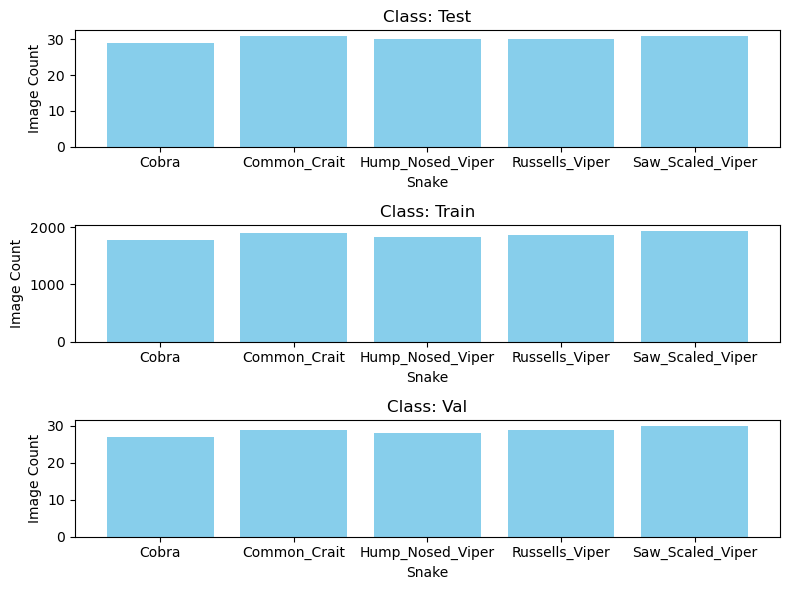

In [3]:
def plot_image_counts(dataset_folder):
    class_counts = {}

    for class_folder in os.listdir(dataset_folder):
        class_path = os.path.join(dataset_folder, class_folder)
        if os.path.isdir(class_path):
            class_counts[class_folder] = []
            for snake_folder in os.listdir(class_path):
                snake_path = os.path.join(class_path, snake_folder)
                if os.path.isdir(snake_path):
                    image_count = len([f for f in os.listdir(snake_path) if f.endswith(('.png', '.jpg', '.jpeg'))])
                    class_counts[class_folder].append((snake_folder, image_count))

    # Plotting
    fig, axes = plt.subplots(nrows=len(class_counts), ncols=1, figsize=(8, 6))
    for i, (class_name, counts) in enumerate(class_counts.items()):
        snakes, image_counts = zip(*counts)
        axes[i].bar(snakes, image_counts, color='skyblue')
        axes[i].set_title(f"Class: {class_name}")
        axes[i].set_xlabel("Snake")
        axes[i].set_ylabel("Image Count")

    plt.tight_layout()
    plt.show()

# Example usage:
dataset_folder = "Dataset"  # Replace with your dataset path

plot_image_counts(dataset_folder)

In [7]:
IM_WIDTH, IM_HEIGHT = 224, 224
NB_EPOCHS = 3
BAT_SIZE = 32
FC_SIZE = 128
NB_MN_LAYERS_TO_FREEZE = 20
dataset_folder = "C:\\Users\\Sandusha\\FYP\\Dataset"
train_dir = "Dataset/Train"
val_dir = "Dataset/Val"
test_dir = "Dataset/Test"

def get_nb_files(directory):
    count = 0
    for root, dirs, files in os.walk(directory):
        count += len(files)
    return count


Found 9290 images belonging to 5 classes.
Found 143 images belonging to 5 classes.



Epoch 1/3


290/290 [==============================] - 373s 1s/step - loss: 0.4026 - accuracy: 0.8502 - val_loss: 0.3591 - val_accuracy: 0.8906
Epoch 2/3
290/290 [==============================] - 356s 1s/step - loss: 0.2214 - accuracy: 0.9196 - val_loss: 0.4964 - val_accuracy: 0.8594
Epoch 3/3
290/290 [==============================] - 352s 1s/step - loss: 0.1837 - accuracy: 0.9335 - val_loss: 0.5409 - val_accuracy: 0.8281
Epoch 1/3
290/290 [==============================] - 518s 2s/step - loss: 0.2691 - accuracy: 0.9034 - val_loss: 0.5008 - val_accuracy: 0.8516
Epoch 2/3
290/290 [==============================] - 508s 2s/step - loss: 0.1702 - accuracy: 0.9361 - val_loss: 0.3983 - val_accuracy: 0.8750
Epoch 3/3
290/290 [==============================] - 510s 2s/step - loss: 0.1451 - accuracy: 0.9455 - val_loss: 0.3592 - val_accuracy: 0.8906
INFO:tensorflow:Assets written to: mobilenet-ft.model\assets

INFO:tensorflow:Assets written to: mobilenet-ft.model\assets


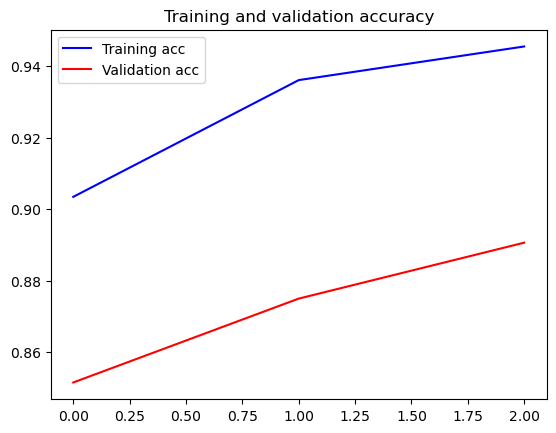

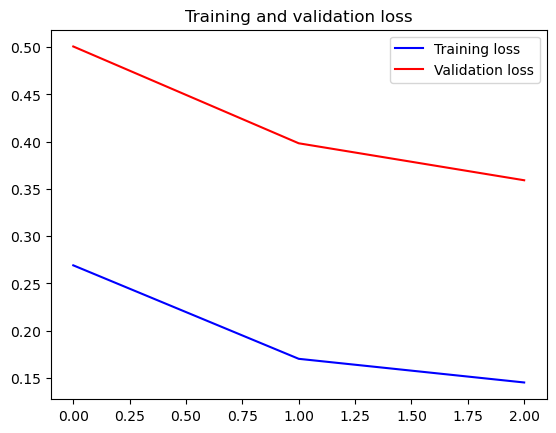

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 conv1 (Conv2D)              (None, 112, 112, 32)      864       
                                                                 
 conv1_bn (BatchNormalizati  (None, 112, 112, 32)      128       
 on)                                                             
                                                                 
 conv1_relu (ReLU)           (None, 112, 112, 32)      0         
                                                                 
 conv_dw_1 (DepthwiseConv2D  (None, 112, 112, 32)      288       
 )                                                               
                                                                 
 conv_dw_1_bn (BatchNormali  (None, 112, 112, 32)      128   

 )                                                               
                                                                 
 conv_dw_8_bn (BatchNormali  (None, 14, 14, 512)       2048      
 zation)                                                         
                                                                 
 conv_dw_8_relu (ReLU)       (None, 14, 14, 512)       0         
                                                                 
 conv_pw_8 (Conv2D)          (None, 14, 14, 512)       262144    
                                                                 
 conv_pw_8_bn (BatchNormali  (None, 14, 14, 512)       2048      
 zation)                                                         
                                                                 
 conv_pw_8_relu (ReLU)       (None, 14, 14, 512)       0         
                                                                 
 conv_dw_9 (DepthwiseConv2D  (None, 14, 14, 512)       4608      
 )        

In [14]:
from keras.applications import MobileNet
from keras.applications.mobilenet import preprocess_input as preprocess_input_mobilenet
from tensorflow.keras.applications.mobilenet import preprocess_input as preprocess_input_tf_mobilenet

def add_new_last_layer_mobilenet(base_model, nb_classes):
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(FC_SIZE, activation='relu')(x)
    predictions = Dense(nb_classes, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=predictions)
    return model

def setup_to_transfer_learn_mobilenet(model, base_model):
    for layer in base_model.layers:
        layer.trainable = False
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

def setup_to_finetune_mobilenet(model):
    for layer in model.layers[:NB_MN_LAYERS_TO_FREEZE]:
        layer.trainable = False
    for layer in model.layers[NB_MN_LAYERS_TO_FREEZE:]:
        layer.trainable = True
    model.compile(optimizer=SGD(learning_rate=0.0001, momentum=0.9), loss='categorical_crossentropy', metrics=['accuracy'])

def plot_training(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(len(acc))

    plt.plot(epochs, acc, 'b', label='Training acc')
    plt.plot(epochs, val_acc, 'r', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.legend()

    plt.figure()

    plt.plot(epochs, loss, 'b', label='Training loss')
    plt.plot(epochs, val_loss, 'r', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()

    plt.show()

def train_mobilenet(train_dir, val_dir, nb_epoch=NB_EPOCHS, batch_size=BAT_SIZE, output_model_file="mobilenet-ft.model", plot=True):
    nb_train_samples = get_nb_files(train_dir)
    nb_classes = len(glob.glob(train_dir + "/*"))
    nb_val_samples = get_nb_files(val_dir)

    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input_tf_mobilenet,
        rotation_range=30,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        fill_mode='nearest',  # Filling strategy for rotated images
    )

    val_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input_tf_mobilenet,
        rotation_range=30,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        vertical_flip=True,
        fill_mode='nearest',
    )
    
    train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(IM_WIDTH, IM_HEIGHT),
        batch_size=batch_size,
        class_mode='categorical'
    )

    validation_generator = val_datagen.flow_from_directory(
        val_dir,
        target_size=(IM_WIDTH, IM_HEIGHT),
        batch_size=batch_size,
        class_mode='categorical'
    )

    base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(IM_WIDTH, IM_HEIGHT, 3))
    model = add_new_last_layer_mobilenet(base_model, nb_classes)

    setup_to_transfer_learn_mobilenet(model, base_model)

    history_tl = model.fit(
        train_generator,
        epochs=nb_epoch,
        steps_per_epoch=nb_train_samples // batch_size,
        validation_data=validation_generator,
        validation_steps=nb_val_samples // batch_size,
        
    )

    setup_to_finetune_mobilenet(model)

    history_ft = model.fit(
        train_generator,
        steps_per_epoch=nb_train_samples // batch_size,
        epochs=nb_epoch,
        validation_data=validation_generator,
        validation_steps=nb_val_samples // batch_size,
        
    )

    model.save(output_model_file)

    if plot:
        plot_training(history_ft)

    return model

# Train the MobileNet model and get the trained model
trained_mobilenet_model = train_mobilenet(train_dir=train_dir, val_dir=val_dir, nb_epoch=NB_EPOCHS, batch_size=BAT_SIZE, output_model_file="mobilenet-ft.model", plot=True)

# Display the model summary
trained_mobilenet_model.summary()

In [13]:
from keras.preprocessing import image
from keras.applications.mobilenet_v2 import preprocess_input
import numpy as np
import os

def predict_with_mobilenetv2_model(model, img_path, class_labels):
    img = image.load_img(img_path, target_size=(IM_WIDTH, IM_HEIGHT))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    predictions = model.predict(img_array)[0]
    
    # Get the predicted class label
    predicted_class_index = np.argmax(predictions)
    predicted_class_label = class_labels[predicted_class_index]

    # Get the actual class label from the folder name
    actual_class_label = os.path.basename(os.path.dirname(img_path))

    return actual_class_label, predicted_class_label, predictions[predicted_class_index]

# Example usage:
test_folder_path = "Dataset\Test"  # Replace with the path to your test folder

class_labels = ["Cobra", "Common_Crait", "Hump_Nosed_Pit_Viper", "Russells_Viper", "Saw_Scaled_Viper"]

for class_folder in os.listdir(test_folder_path):
    class_folder_path = os.path.join(test_folder_path, class_folder)

    for img_name in os.listdir(class_folder_path):
        img_path = os.path.join(class_folder_path, img_name)

        # Make predictions for the current image
        actual_label, predicted_label, confidence = predict_with_mobilenetv2_model(trained_mobilenetv2_model, img_path, class_labels)

        # Print the predictions for each image
        print(f"Image: {img_name}")
        print(f"Actual Class: {actual_label}")
        print(f"Predicted Class: {predicted_label}")
        print(f"Confidence: {confidence:.4f}")
        print("=" * 30)


1/1 [==============================] - 1s 1s/step
Image: Cobra105.jpg
Actual Class: Cobra
Predicted Class: Cobra
Confidence: 0.9999
1/1 [==============================] - 0s 62ms/step
Image: Cobra12.jpg
Actual Class: Cobra
Predicted Class: Cobra
Confidence: 0.9999
1/1 [==============================] - 0s 53ms/step
Image: Cobra134.jpg
Actual Class: Cobra
Predicted Class: Cobra
Confidence: 0.9956
1/1 [==============================] - 0s 53ms/step
Image: Cobra146.jpg
Actual Class: Cobra
Predicted Class: Cobra
Confidence: 0.9997
1/1 [==============================] - 0s 38ms/step
Image: Cobra149.jpg
Actual Class: Cobra
Predicted Class: Hump_Nosed_Pit_Viper
Confidence: 0.5151
1/1 [==============================] - 0s 53ms/step
Image: Cobra150.jpg
Actual Class: Cobra
Predicted Class: Cobra
Confidence: 0.9976
1/1 [==============================] - 0s 53ms/step
Image: Cobra161.jpg
Actual Class: Cobra
Predicted Class: Cobra
Confidence: 1.0000
1/1 [==============================] - 0s 47ms/ste

1/1 [==============================] - 0s 62ms/step
Image: Common_Crait298.jpg
Actual Class: Common_Crait
Predicted Class: Common_Crait
Confidence: 0.9999
1/1 [==============================] - 0s 69ms/step
Image: Common_Crait39.jpg
Actual Class: Common_Crait
Predicted Class: Common_Crait
Confidence: 0.5535
1/1 [==============================] - 0s 47ms/step
Image: Common_Crait48.jpg
Actual Class: Common_Crait
Predicted Class: Common_Crait
Confidence: 0.9672
1/1 [==============================] - 0s 53ms/step
Image: Common_Crait49.jpg
Actual Class: Common_Crait
Predicted Class: Common_Crait
Confidence: 0.9996
1/1 [==============================] - 0s 53ms/step
Image: Common_Crait5.jpg
Actual Class: Common_Crait
Predicted Class: Common_Crait
Confidence: 0.9960
1/1 [==============================] - 0s 31ms/step
Image: Common_Crait51.jpg
Actual Class: Common_Crait
Predicted Class: Common_Crait
Confidence: 1.0000
1/1 [==============================] - 0s 47ms/step
Image: Common_Crait7.jpg

1/1 [==============================] - 0s 38ms/step
Image: Russells_Viper1.jpg
Actual Class: Russells_Viper
Predicted Class: Russells_Viper
Confidence: 0.9999
1/1 [==============================] - 0s 53ms/step
Image: Russells_Viper100.jpg
Actual Class: Russells_Viper
Predicted Class: Russells_Viper
Confidence: 1.0000
1/1 [==============================] - 0s 53ms/step
Image: Russells_Viper120.jpg
Actual Class: Russells_Viper
Predicted Class: Russells_Viper
Confidence: 1.0000
1/1 [==============================] - 0s 38ms/step
Image: Russells_Viper124.jpg
Actual Class: Russells_Viper
Predicted Class: Russells_Viper
Confidence: 1.0000
1/1 [==============================] - 0s 53ms/step
Image: Russells_Viper144.jpg
Actual Class: Russells_Viper
Predicted Class: Russells_Viper
Confidence: 0.9996
1/1 [==============================] - 0s 47ms/step
Image: Russells_Viper154.jpg
Actual Class: Russells_Viper
Predicted Class: Russells_Viper
Confidence: 0.9973
1/1 [==============================]

1/1 [==============================] - 0s 47ms/step
Image: Saw_Scaled_Viper203.jpg
Actual Class: Saw_Scaled_Viper
Predicted Class: Saw_Scaled_Viper
Confidence: 0.9847
1/1 [==============================] - 0s 47ms/step
Image: Saw_Scaled_Viper216.jpg
Actual Class: Saw_Scaled_Viper
Predicted Class: Hump_Nosed_Pit_Viper
Confidence: 0.9563
1/1 [==============================] - 0s 47ms/step
Image: Saw_Scaled_Viper23.jpg
Actual Class: Saw_Scaled_Viper
Predicted Class: Saw_Scaled_Viper
Confidence: 0.9988
1/1 [==============================] - 0s 47ms/step
Image: Saw_Scaled_Viper233.jpg
Actual Class: Saw_Scaled_Viper
Predicted Class: Saw_Scaled_Viper
Confidence: 1.0000
1/1 [==============================] - 0s 47ms/step
Image: Saw_Scaled_Viper237.jpg
Actual Class: Saw_Scaled_Viper
Predicted Class: Saw_Scaled_Viper
Confidence: 1.0000
1/1 [==============================] - 0s 38ms/step
Image: Saw_Scaled_Viper243.jpg
Actual Class: Saw_Scaled_Viper
Predicted Class: Russells_Viper
Confidence: 0.67